In [12]:
import pandas as pd
import numpy as np
from utils import preprocess
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.dates as mdates

In [13]:
df = pd.read_csv("data/1082-Device-Data-Fix.csv")
df = preprocess.get_clean_df(df)

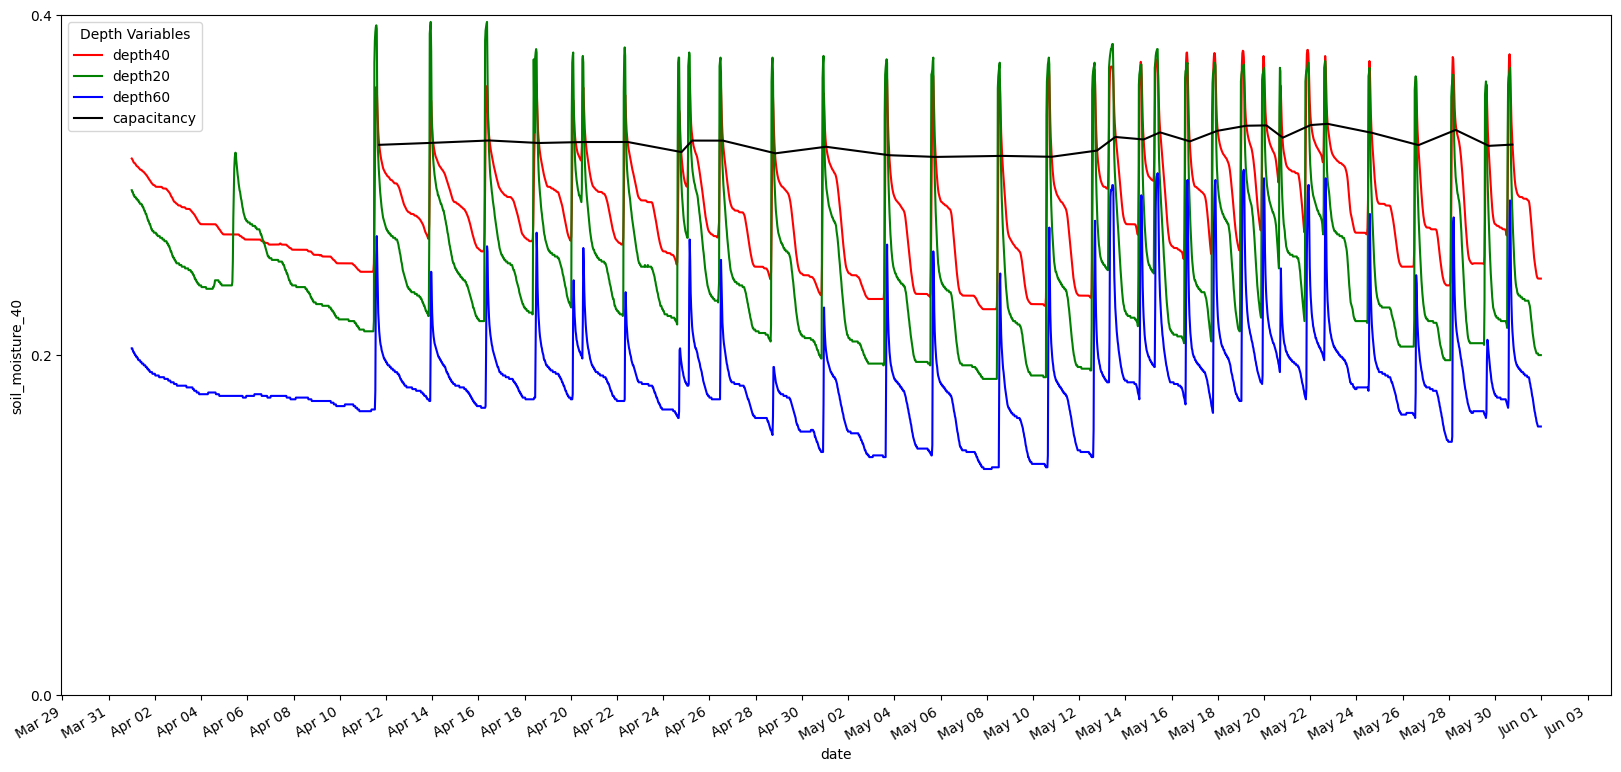

In [14]:
start_date = pd.to_datetime("2024-04-01")
end_date   = pd.to_datetime("2023-05-10")
df_constricted = df[(df["date"].dt.month >= start_date.month) & (df["date"].dt.month <= end_date.month) & (df["date"].dt.year <= end_date.year)].copy()
values = df_constricted["soil_moisture_40"].to_numpy()
df_constricted["soil_moisture_40"] = gaussian_filter1d(values, 1)

capacitancy_frame = preprocess.get_capacitancy_points(df_constricted)

plt.figure(figsize=(20, 10))
sns.lineplot(df_constricted, x="date", y="soil_moisture_40", label="depth40", color="red")
sns.lineplot(df_constricted, x="date", y="soil_moisture_20", label="depth20", color="green")
sns.lineplot(df_constricted, x="date", y="soil_moisture_60", label="depth60", color="blue")
sns.lineplot(capacitancy_frame, x="date", y="capacitancy", label="capacitancy", color="black")
plt.legend(title="Depth Variables")
plt.ylim(0, 0.40)
plt.yticks([0, 0.20, 0.40])
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gcf().autofmt_xdate()  # rotate labels for clarity
plt.show()